# Notebook 3: Building up to quantum cellular automata - Semiclassical cellular automata

Roadplan:
- Building up Markov transition matrices
- Change dynamics function so that it uses a probabilistic approach for the cells given or the entire lattice.
- Look at other function to change
- Plot some classical vs semiclassical
- Extending markov chains to semiclassical automata

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

In [77]:
# From Notebook 1

from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

In [78]:
# From Notebook 2
from Functions_for_Notebook_2 import plot_grid_multiple, plot_multiple_cells, dynamics_initialandfinal #To grid multiple systems

from Functions_for_Notebook_2 import is_rule

from Functions_for_Notebook_2 import is_reversible, gardens_of_eden

## 1. Building up Markov Transition Matrices
https://www.youtube.com/watch?v=Hmzfv9dqw94

https://www.youtube.com/watch?v=i3AkTO9HLXo&list=PLM8wYQRetTxBkdvBtz-gw8b9lcVkdXQKV

General markov chains have the characteristic that the future state only depends on the current state and the probabilities of all posssible subsequent states add up to one (just like elementary CA).

Therefore, a transition matrix can be computed for the evolution of CA system, dependent on the rule and lattice length.

The end goal is to have two functions that print out a vector representation of the initial state and a function that prints out the transition matric for that evolution.

In [79]:
def vectorized_ic(L, initial_conditions):
    import itertools
    
    # build the lattice row — length L
    row = np.zeros(L, dtype=int)
    row[initial_conditions] = 1       
    
    # find which index in all_states this corresponds to
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = all_states.index(tuple(row))  
    
    # return a vector of length 2^L with a 1 at that index
    v = np.zeros(2**L, dtype=int)
    v[index] = 1
    return v

print(vectorized_ic(10, [1,3,5]))

print(vectorized_ic(2, [1]))

[0 0 0 ... 0 0 0]
[0 1 0 0]


This vectorized_is function takes the state defined by L and the initial conditions and returns a probability vector where all components are 0 except for the i'th component, which is one, where i is the component at the position that that same position later occupies in the transition matrix.

The next_state function is just for convenience:

In [80]:
def next_state(state, rule_number, L): #This code comes up in several functions so it is better to automate it
    rule   = make_rule(rule_number)
    result = []
    for i in range(L):
        left   = str(int(state[i - 1])) if i > 0 else '0'      
        center = str(int(state[i]))
        right  = str(int(state[i + 1])) if i < L - 1 else '0'    
        neighbourhood = left + center + right
        result.append(rule[neighbourhood])
    return tuple(result)

print(next_state([1,0,1,0], 255, 4))
print("")
print(next_state([1,0,1,0], 0, 4))
print("")
print(next_state([1,0,1,1], 90, 4))
print(next_state([1,1,1,0], 90, 4))
print(next_state([0,1,1,1], 90, 4))

(1, 1, 1, 1)

(0, 0, 0, 0)

(0, 0, 1, 1)
(1, 0, 1, 1)
(1, 1, 0, 1)


The logic behind the Markov chain will be that the i and j will be the input and output possible lattices, so it will be a permutation of the lattice length, meaning the markov chain for larger lattices will not be an efficient approach:

In [81]:
def markov_matrix_mapping(rule_number: int, L: int):
    import itertools

    rule       = make_rule(rule_number)
    all_states = list(itertools.product([0, 1], repeat=L))
    n          = len(all_states)

    M = np.zeros((n, n), dtype=int)

    state_labels = [''.join(str(b) for b in s) for s in all_states]
    print(f"\nTransition matrix — Rule {rule_number}, L={L}")
    print(f"Row = current state   Col = next state\n")
    print("        " + "  ".join(state_labels))
    print("       " + "---" * n)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)   
        i   = all_states.index(nxt)
        label = ''.join(str(b) for b in state)
        row   = "  ".join(str(M[k][j]) for k in range(n))
        print(f"{label}  |  {row}")



def markov_matrix(rule_number: int, L: int):
    import itertools

    rule = make_rule(rule_number)
    all_states = list(itertools.product([0, 1], repeat=L))
    n  = len(all_states)

    M = np.zeros((n, n), dtype=int)

    state_labels = [''.join(str(b) for b in s) for s in all_states]

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)   
        i   = all_states.index(nxt)
        M[i][j] = 1
        label = ''.join(str(b) for b in state)
        row  = "  ".join(str(M[k][j]) for k in range(n))

    return M

print(markov_matrix_mapping(0, 2 ))

print(markov_matrix(0, 2 ))

print(markov_matrix(255, 2 ))


Transition matrix — Rule 0, L=2
Row = current state   Col = next state

        00  01  10  11
       ------------
00  |  0  0  0  0
01  |  0  0  0  0
10  |  0  0  0  0
11  |  0  0  0  0
None
[[1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]]


In [82]:
result = markov_matrix(3, 3) @ vectorized_ic(3, [1,2])

result 

array([0, 0, 0, 0, 1, 0, 0, 0])

### Proving the function works:
To prove the Markov chain approach works, we build up two functions that perform the same, obtaining the state of a system at a certain timestep.

First version of the function does that through the dynamics function:

In [83]:
system = dynamics(99, 10, [1,4,7], 10)

In [84]:
def state_timestep_1(system, timestep):
    return system[-(timestep + 1)]

print(state_timestep_1(system, 3))

print(state_timestep_1(system, 0))

[1 1 0 0 1 0 0 1 0 0]
[0 1 0 0 1 0 0 1 0 0]


The second version computes the timestep as a matrix multiplication:

In [85]:
rule = 3
ic = [1,2]
system = dynamics(rule, 3, ic, 10)

def state_timestep_2(rule, system, ic, timestep):
    L = len(system[-1])
    v = vectorized_ic(L, ic)
    M =  markov_matrix(rule, L)

    for _ in range(timestep):
        v = M @ v

    #Convert the probability vector back into the cell values
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = np.argmax(v) 
    return np.array(all_states[index])

print(state_timestep_2(rule, system, ic, 3))

print(state_timestep_2(rule, system,ic, 0))

[1 1 0]
[0 1 1]


Now we verify that this matches for different systems:

In [86]:
ic =[5,7]
timestep = 10
L = 10
rule = 90

system_1 = dynamics(rule, 10, ic, timestep)
system_2 = dynamics(rule, 10, ic, timestep)
system_3 = dynamics(rule, 10, ic, timestep)
system_4 = dynamics(rule, 10, ic, timestep)
system_5 = dynamics(rule, 10, ic, timestep)

lst = [system_1, system_2, system_3, system_4, system_5]


all_match = True  


for system in lst:
    for t in range(10):
        s1 = state_timestep_1(system, timestep)
        s2 = state_timestep_2(rule, system, ic, timestep)
        if not np.allclose(s1, s2):
            all_match = False
            break      
    if not all_match:
        break      

print(all_match)
        

   

True


We'll stick to the first approach because it requires less inputs and works for longer lattices:

In [87]:
def state_timestep(system, timestep):
    return system[:timestep]

## 2. Study of Markov Transition Matrices

## 3. Adjusting previous functions to account for a probabilistic approach
### 1.1) Dynamics function

First, we define a function for probablistic approaches and see if it can be tirned into a generalization of the previous dynamics function.

Firstly, define a new function that for the initial conditions has an associated list with the probability that it is one, then add an option such that if only one value is put in for the probabilities, then that probability applied for all initial conditions. We can also define it such that if no probabilities are specified, the function reverts back to its classical version. 

In [88]:
def probabilistic_dynamics(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(probabilistic_dynamics(3, 9, [], None , 9))
print(probabilistic_dynamics(3, 9, [1,2,3], [0.3,0.6,0.7] , 9))

[[1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]]
[[1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 1 0]
 [1 1 1 1 1 0 0 0 1]
 [0 0 0 0 0 1 1 0 0]
 [1 1 1 1 0 0 0 1 1]
 [0 0 0 0 1 1 0 0 0]
 [1 1 1 0 0 0 1 1 1]
 [0 0 0 1 1 0 0 0 0]
 [1 1 0 0 0 1 1 1 1]
 [0 0 1 1 0 0 0 0 0]]


To prove it works, we can prove it in different steps: 

1. The semiclassical arrays for the case where the probability is zero must match the classical dynamics that don't include the value for which the probabolity is zero as an initial starting point in the first place.

In [89]:
np.allclose(probabilistic_dynamics(23, 10, [1,2,3, 4], [1,1,1, 0], 10), dynamics(23, 10, [1,2,3], 10))

np.allclose(probabilistic_dynamics(23, 1000, [1,20,33, 4], [1,1,1, 0], 1000), dynamics(23, 1000, [1,20,33], 1000))



True

2. The absolute same function can give different results and will most likely for a large number of initial conditions

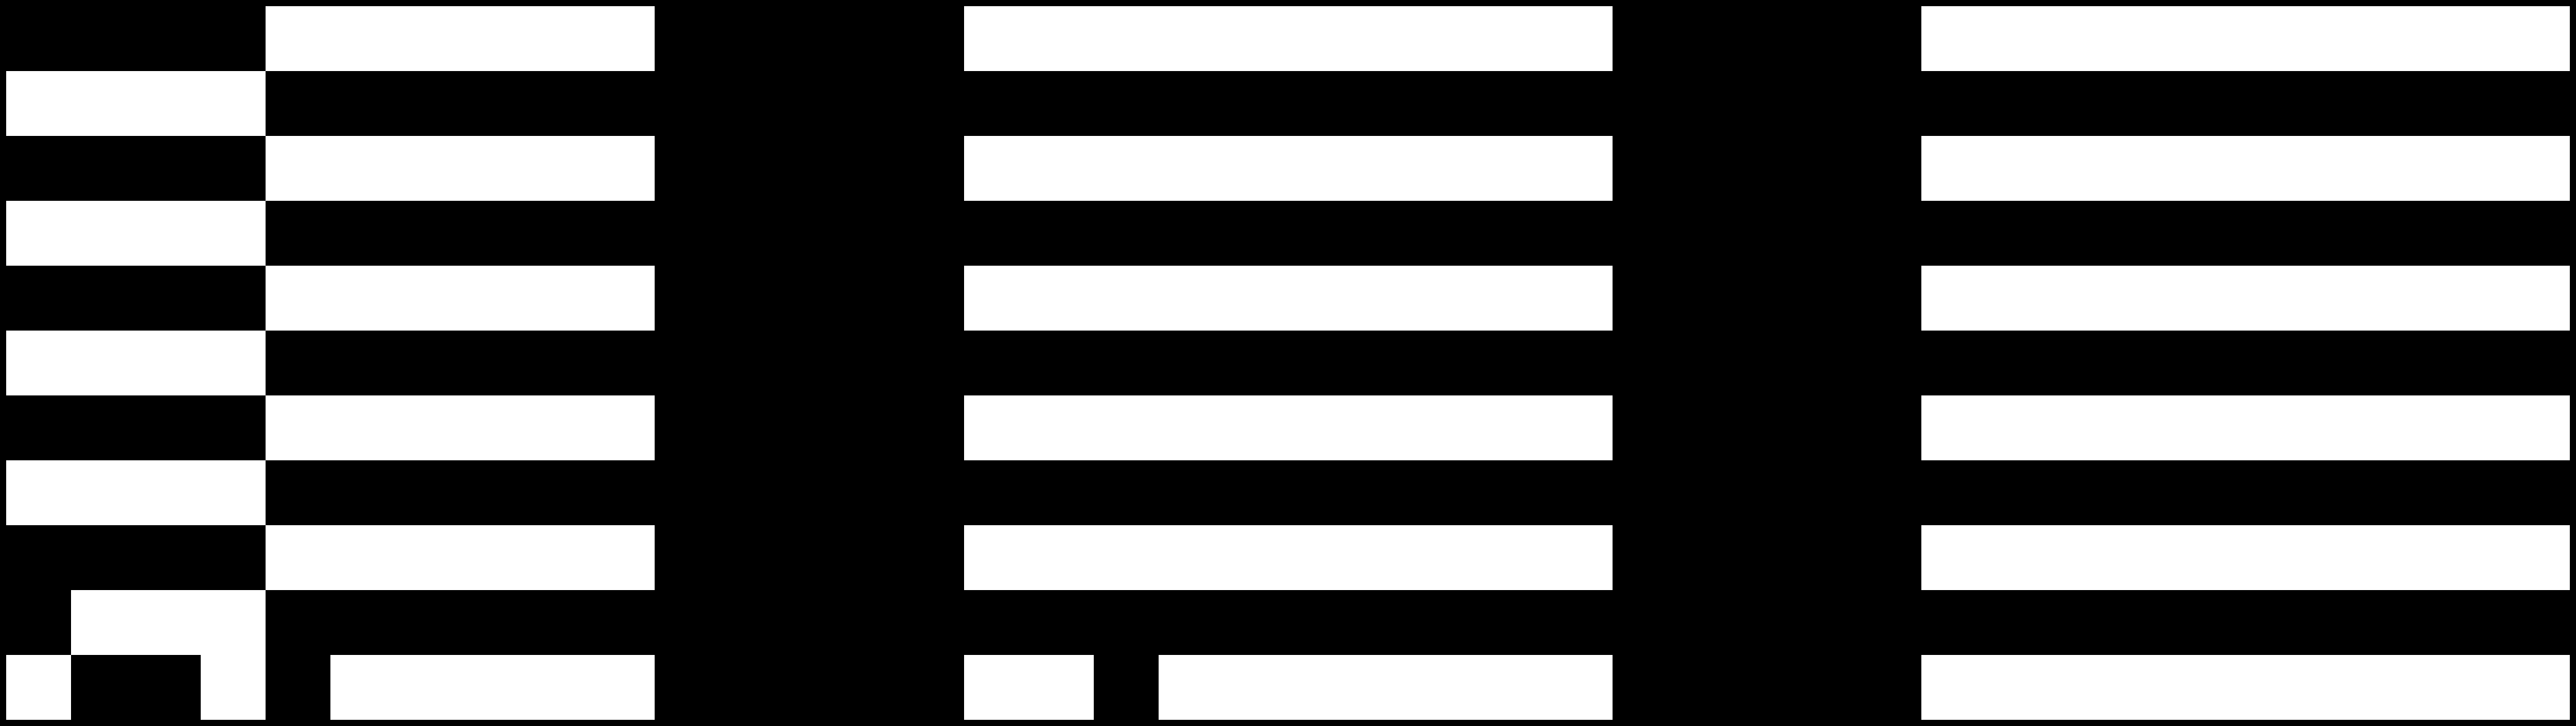

In [90]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10)], cols=3)

### 1.2) Other functions


Other functions that can / must be adjusted to account for semiprobabilistic conditions are the following:
- Dynamics functions for the different boundary conditions
- The markov chains

The markov chains will be dealt with in a different section:

In [91]:
def probabilistic_dynamics_periodic(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics_periodic(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][(j - 1) % L]))  # periodic boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][(j + 1) % L]))   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

In [92]:
def probabilistic_dynamics_reflection(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics_reflection(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j + 1])) if j == 0 else str(int(rows[-1][j - 1]))  #mirror reflection
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j - 1])) if j == L - 1 else str(int(rows[-1][j + 1]))
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

In [93]:
def probabilistic_dynamics_initialandfinal(rule_number, L, initial_conditions, probability_list, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropriate")
    
    if probability_list is None:
        return dynamics_initialandfinal(rule_number, L, initial_conditions, timesteps)
    
    elif isinstance(probability_list, float):
        new_list = []
        for i in range(len(initial_conditions)):
            new_list.append(probability_list)
        probability_list = new_list

    elif len(initial_conditions) != len(probability_list):
        raise ValueError("Each initial condition must have an associated probability")

    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)

    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0
    rows = [row.copy()] #So we take an independent "snapshot"


    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j - 1])) if j > 0 else '0'       # zero boundary
            centre = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j + 1])) if j < L - 1 else '0'   # zero boundary
            neighbourhood = left + centre + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return rows[0], "->", rows[-1]

## 2. Plotting rules against their semiclassical counterparts
Comparing the evolution of semiclassical systems to their purely classical counterparts.

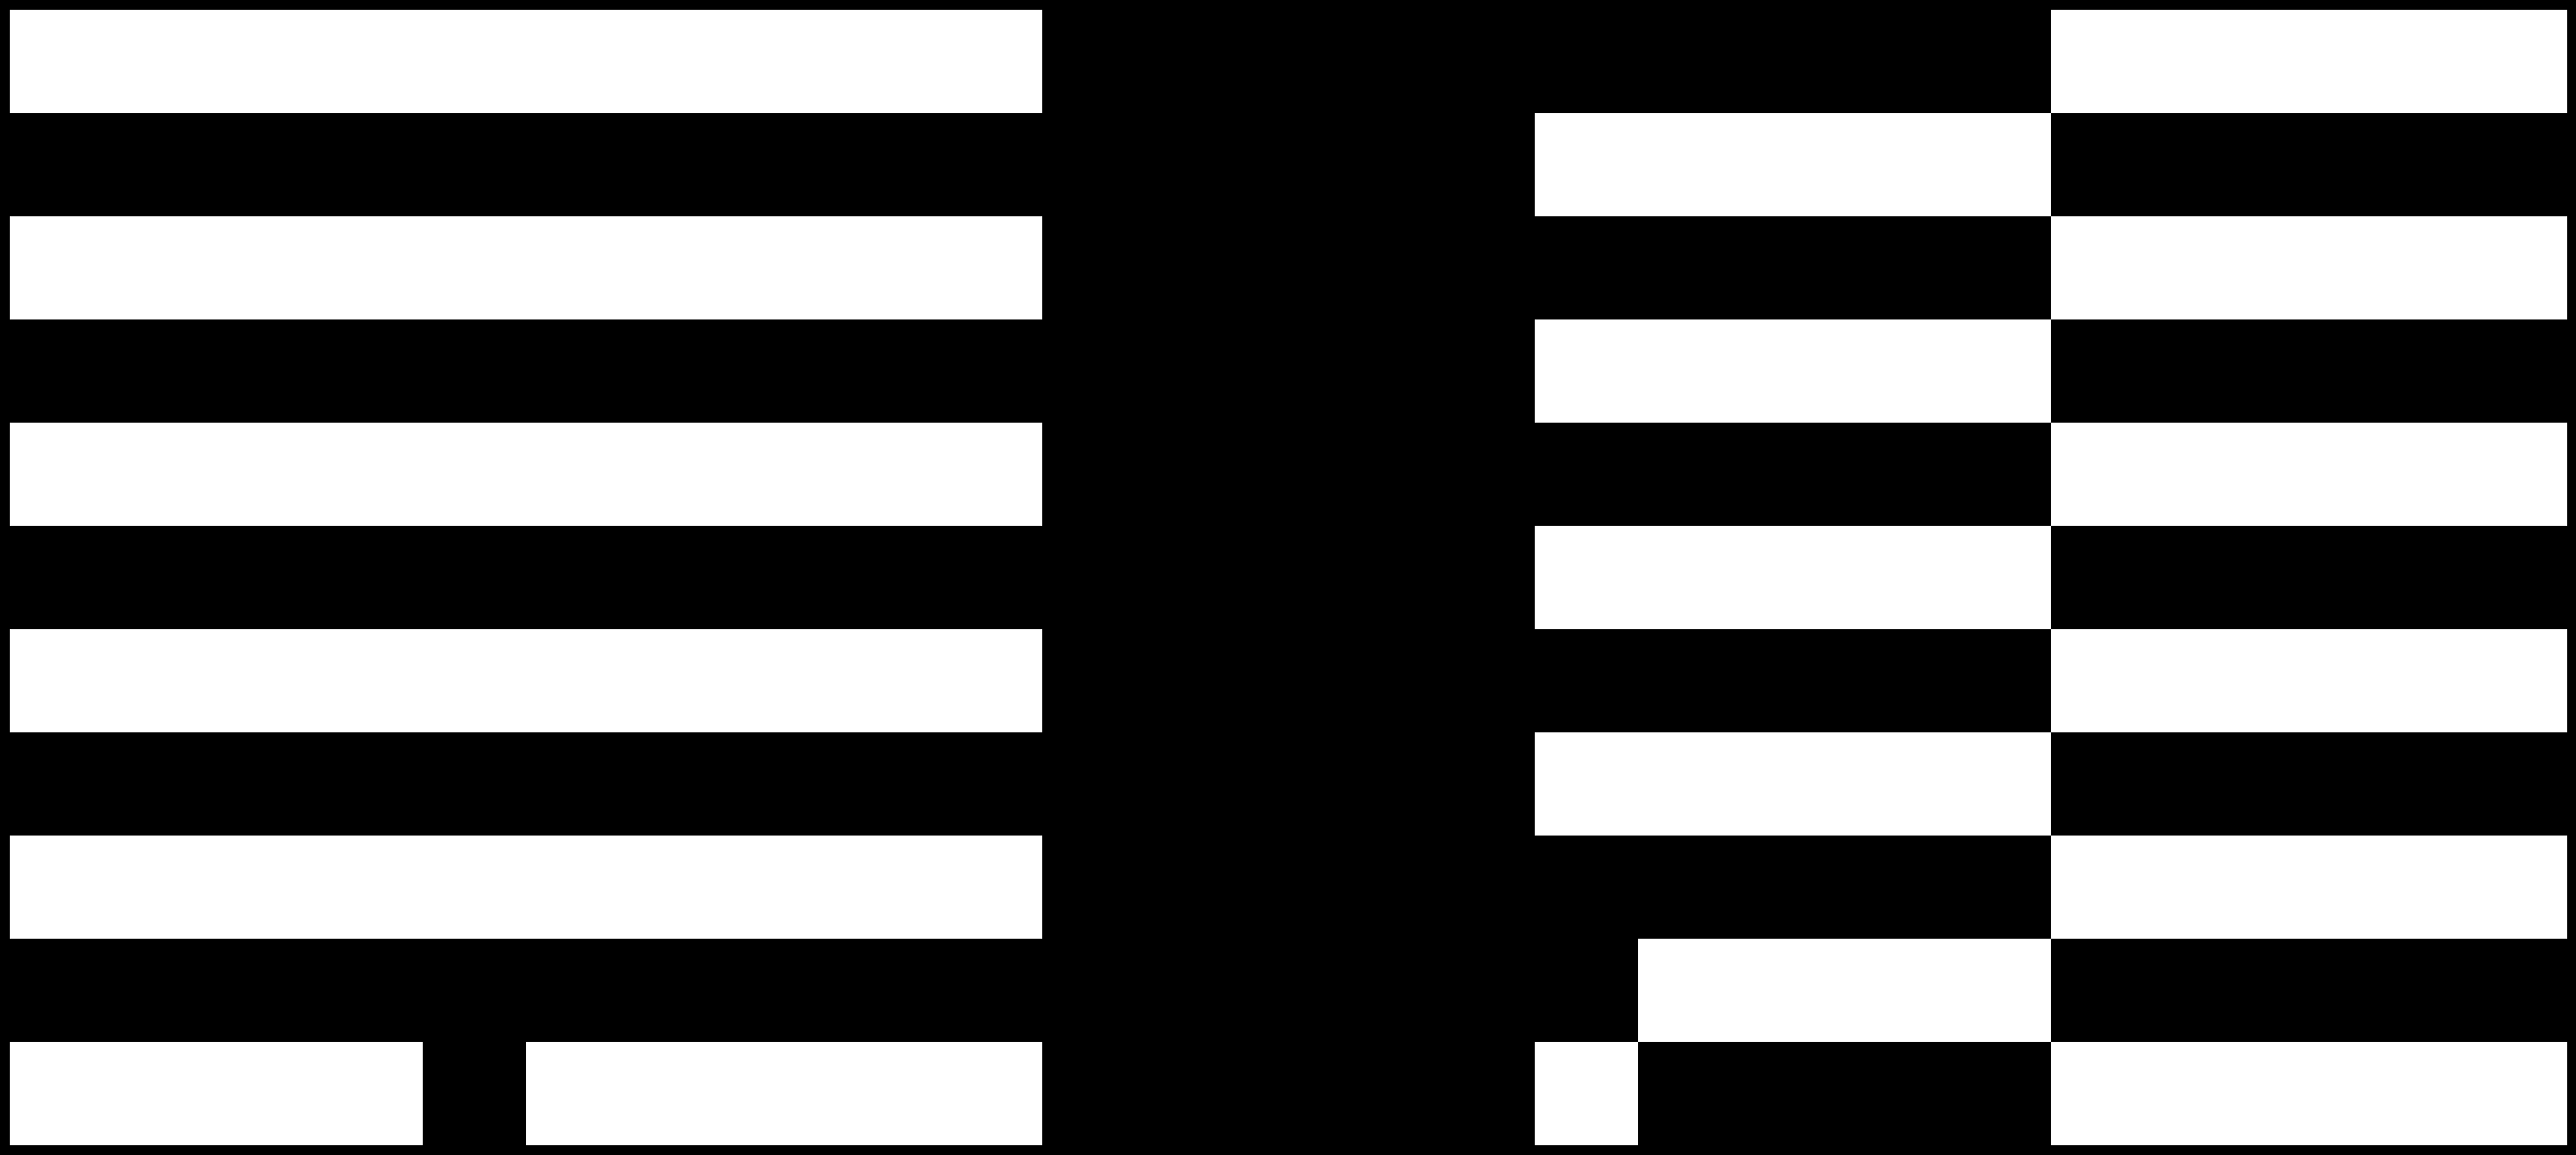

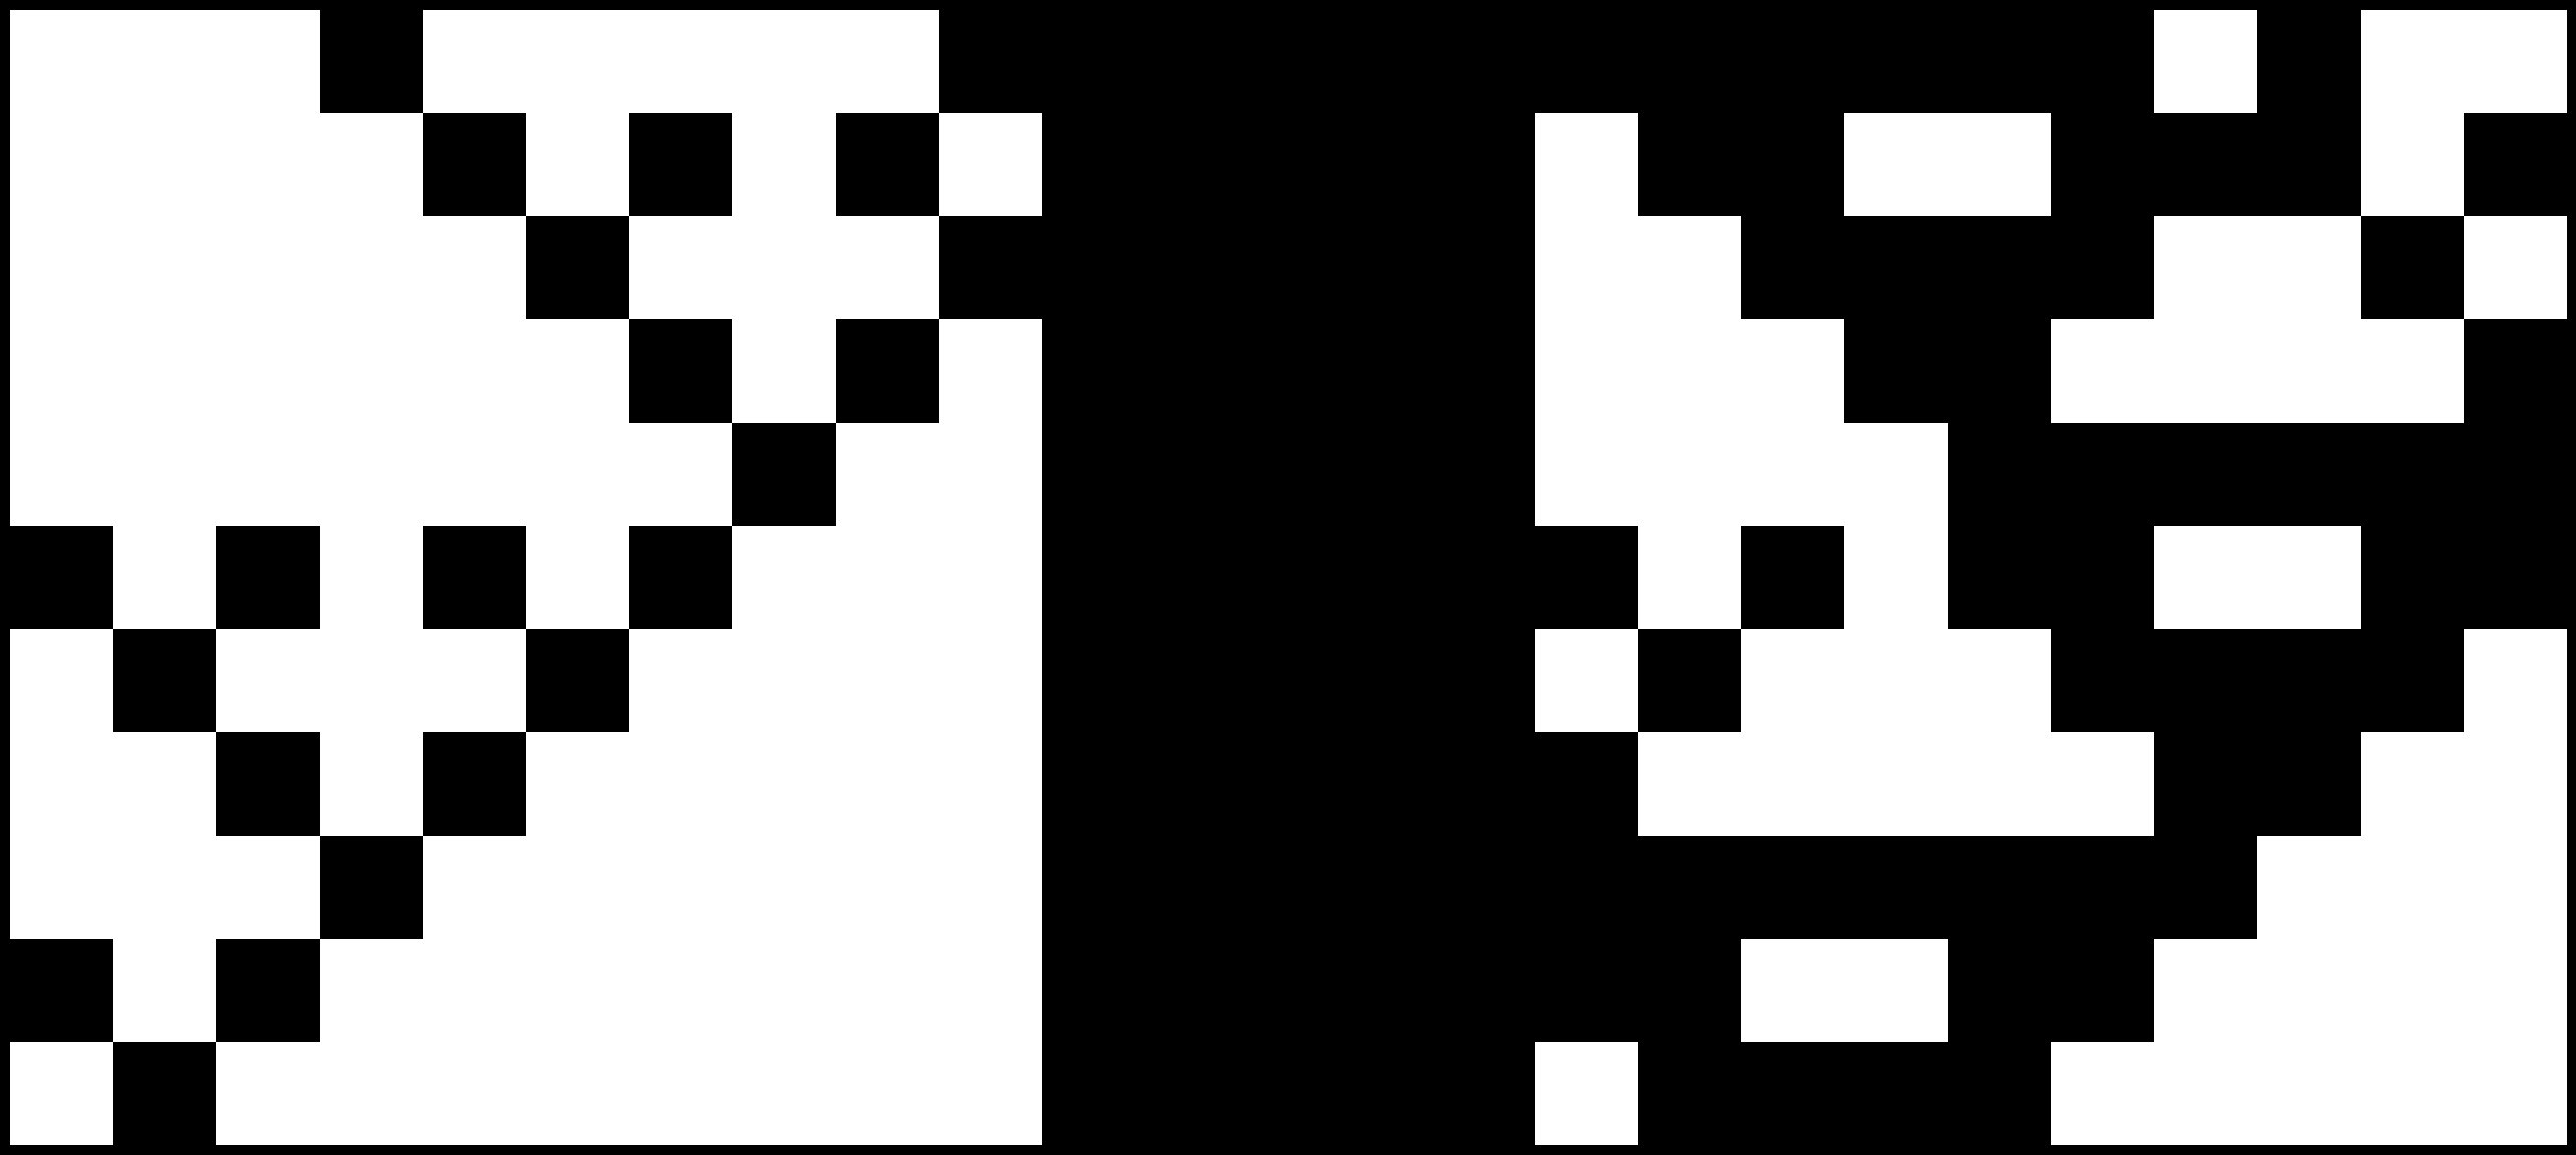

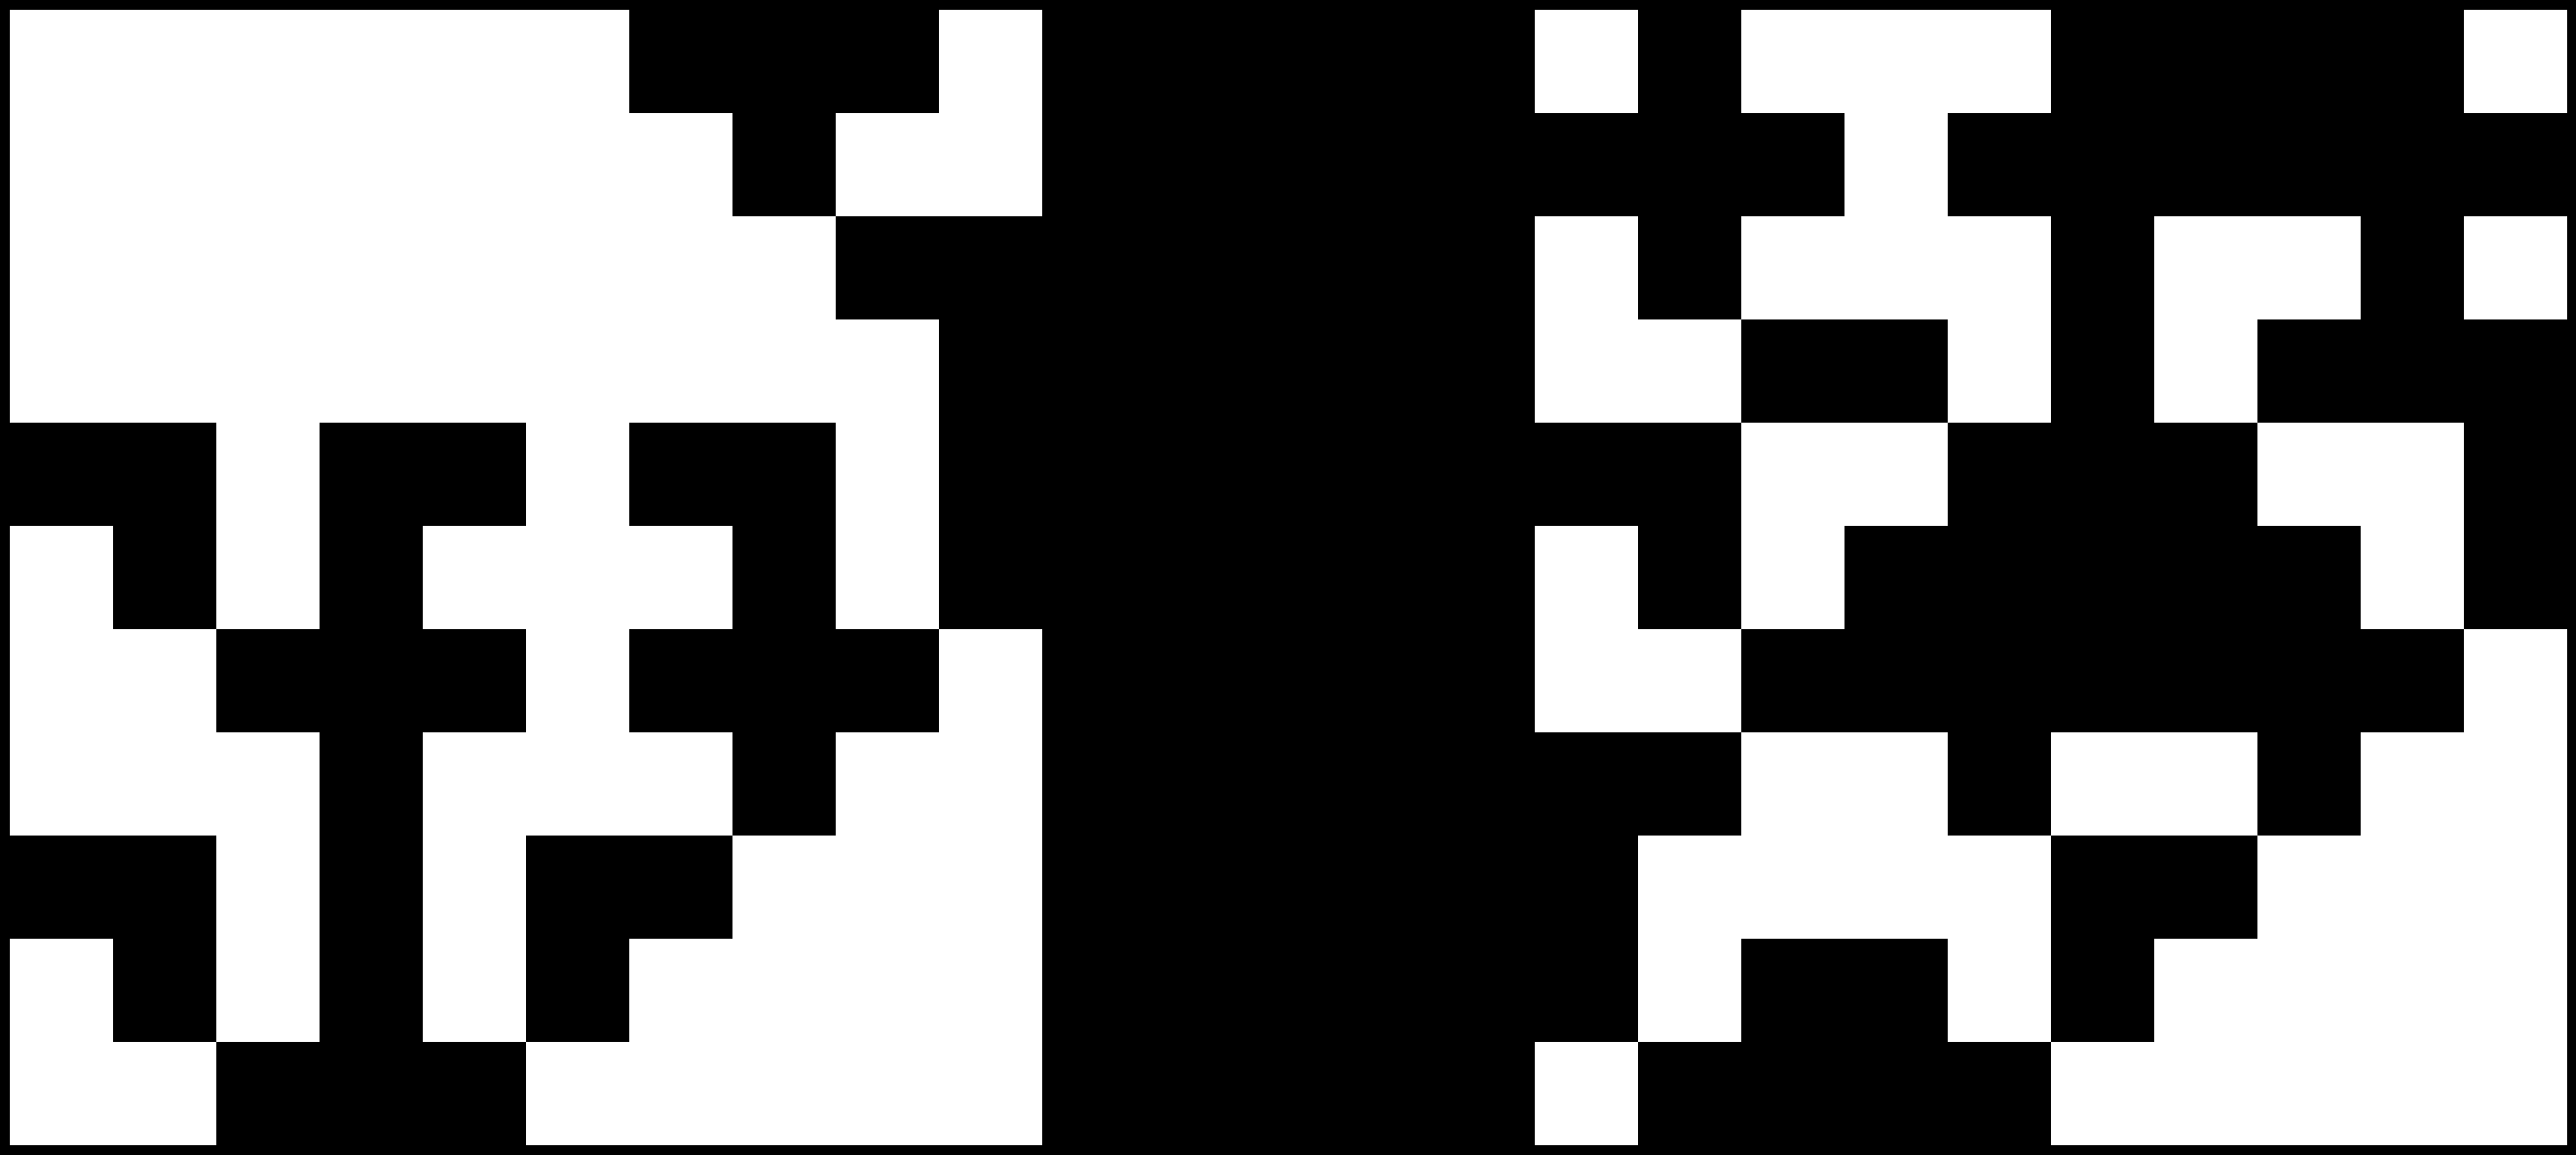

In [94]:
plot_grid_multiple([probabilistic_dynamics(23, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(23, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(90, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(90, 10, [1,2,3,4], 10)], cols=3)

plot_grid_multiple([probabilistic_dynamics(150, 10, [1,2,3,4], [0.5,0.5,0.5,0.5], 10), dynamics(150, 10, [1,2,3,4], 10)], cols=3)

## 3. Creating Markov Chains for semiclassicla CA
The function for a semiclassical Markov chain will have the same structure as the previous Markov chain but instead of values of 1 and 0 corresponding to 100 and 0% you get values within the range of 0 and 1 corresponding to different probabilities. NO

The matrix itself will not change because the evolution is still deterministic and has no associated probability, what will change is the vectorized initial conditions.

In [95]:
def vectorized_ic_probabilistic(L, initial_conditions, probability_list: list):
    import itertools
    
    # build the lattice row — length L
    row = np.zeros(L, dtype=int)
    for i, probability in zip(initial_conditions, probability_list):
        row[i] = 1 if random.random() < probability else 0       
    
    # find which index in all_states this corresponds to
    all_states = list(itertools.product([0, 1], repeat=L))
    index      = all_states.index(tuple(row))  
    
    # return a vector of length 2^L with a 1 at that index
    v = np.zeros(2**L, dtype=int)
    v[index] = 1
    return v

But can we use Markov chains to simulate a probabilistic evolution, let's say that for each binary number that maps out to one, we can denote a certain probability that it actually does map to one, whereas the combinations that map out to zero always do map out to zero.

In [96]:
def markov_matrix_mapping_probabilistic(rule_number: int, L: int, p: float):
    all_states   = list(itertools.product([0, 1], repeat=L))
    n = len(all_states)
    M = np.zeros((n, n), dtype=float)

    state_labels = [''.join(str(b) for b in s) for s in all_states]
    print(f"\nProbabilistic Transition matrix — Rule {rule_number}, L={L}, p={p}")
    print(f"Row = next state   Col = current state\n")
    print("        " + "  ".join(state_labels))
    print("       " + "---" * n)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)

        # bits that rule maps to 0 → always 0
        # bits that rule maps to 1 → 1 with probability p, else 0
        probabilistic_nxt = tuple(
            1 if (bit == 1 and random.random() < p) else 0
            for bit in nxt
        )

        i        = all_states.index(probabilistic_nxt)
        M[i][j]  = 1
        label    = ''.join(str(b) for b in state)
        row      = "  ".join(f"{M[k][j]:.0f}" for k in range(n))
        print(f"{label}  |  {row}")



def markov_matrix_probabilistic(rule_number: int, L: int, p: float):
    all_states = list(itertools.product([0, 1], repeat=L))
    n = len(all_states)
    M = np.zeros((n, n), dtype=float)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)  # deterministic next state

        # build the probabilistic next state
        probabilistic_nxt = tuple(
            1 if (bit == 1 and random.random() < p) else 0
            for bit in nxt
        )
        # bit == 0 → always stays 0
        # bit == 1 → becomes 1 with probability p, else 0

        i = all_states.index(probabilistic_nxt)
        M[i][j] = 1

    return M

Another approach to a probabilistic Markov chain is simulating noise by giving it a random probability such that the mapping is not performed and instead the output is flipped:

In [97]:
def markov_matrix_noise(rule_number: int, L: int, probability: float):
    """
    Normal CA transition matrix but every bit in the output
    has a small probability epsilon of flipping.
    
    probability = 0.0 → identical to normal deterministic markov_matrix
    probability = 0.5 → completely random, rule means nothing
    probability = 1 → like if the rule was inversed
    """

    all_states = list(itertools.product([0, 1], repeat=L))
    n  = len(all_states)
    M = np.zeros((n, n), dtype=float)

    for j, state in enumerate(all_states):
        nxt = next_state(state, rule_number, L)  # deterministic next state

        # apply bit-flip noise to every bit in nxt
        noisy_nxt = tuple(
            (1 - bit) if random.random() < probability else bit
            for bit in nxt
        )

        i = all_states.index(noisy_nxt)
        M[i][j] = 1

    return M

## 4. Spectral properties of these matrices
The spectral properties of a matrix depend on the spectrum or range of the eigenvalues. The eigenvalues and eigenvectors can be obtained through integrated numpy fucntions:

In [98]:
import numpy as np
M = np.array([[1,2,3], 
              [4,5,6], 
              [7,8,9]])


eigenvalues, eigenvectors = np.linalg.eig(M)

For square matrices, the determinant and trace are also obtained through integrated functions. In the case of our Markov matrices, the trace will be the number of states where the state maps out to itself and the determinant will almost always be zero as that means multiple states map out to the same state, if that is not the case, then that means the system will be reversible.

In [99]:
det = np.linalg.det(M)

trace = np.trace(M)

print(det, trace)

def is_reversible_matrix(M):
    if np.linalg.det(M) != 0:
        return True
    else:
        return False

-9.51619735392994e-16 15


The spectral radius is the largest absolute eigenvalue in the spectrum. (what does it measure ?)

In [100]:
import numpy as np

def spectral_radius(M):
    eigenvalues = np.linalg.eig(M)[0]
    return np.max(np.abs(eigenvalues))

print(spectral_radius(M))

16.11684396980703


The spectral gap is the difference between largets and second largest eigenvalue:

In [101]:
import numpy as np

def spectral_gap(M):
    eigenvalues = np.abs(np.linalg.eig(M)[0])  
    eigenvalues = sorted(eigenvalues, reverse=True) 
    eigenvalue_max_1 = eigenvalues[0]  
    eigenvalue_max_2 = eigenvalues[1]   
    return eigenvalue_max_1 - eigenvalue_max_2

print(spectral_gap(M))

14.999999999999986


The algebraic multiplicity is the number of times an eigenvalue is repeated (power of the root of the characteristic polynomial). The geometric multiplicity is the number of linearly independent eigenvectors or dimension of the eigenspace:

In [102]:
import numpy as np

M = np.array([[1, 0, 0, 1],
              [0, 1, 1, 0],
              [0, 1, 1, 0],
              [1, 0, 0, 1]])

def algebraic_multiplicities(M):
    eigvals = np.linalg.eigvals(M) # Direct way to get eigenvalues without slicing
    
    unique_vals = []
    counts = []

    for v in eigvals:
        found = False
        for i, u in enumerate(unique_vals):
            if np.isclose(v, u):
                counts[i] += 1
                found = True
                break
        if not found:
            unique_vals.append(v)
            counts.append(1)

    return list(zip(unique_vals, counts)) # Dictionaries behave strangely with float numbers, so just use tuples in lists

print(algebraic_multiplicities(M))

[(2.0, 2), (0.0, 2)]


In [ ]:
def geometric_multiplicities(M):
    n = M.shape[0]
    eigenvalues = np.linalg.eigvals(M)

    unique_vals = []
    geometric_multiplicity  = []

    for v in eigenvalues:

        if any(np.isclose(v, u) for u in unique_vals):
            continue

        unique_vals.append(v)

        # geometric multiplicity = n - rank(M - λI), more convenient to use this identity instead of 
        # the definition of geometric multiplicity
        null_space_dim = n - np.linalg.matrix_rank(M - v * np.eye(n), tol = 1e-10)
        geometric_multiplicity.append(null_space_dim) # Gave problems with floating point errors otherwise

    return list(zip(unique_vals, geometric_multiplicity )) ### Some of the math has to be off that is why it doesnt work

print(geometric_multiplicities(M))

[(2.0, 1)]


In [107]:
M = np.array([[2, 1],
              [0, 2]])


print(algebraic_multiplicities(M))   
print(geometric_multiplicities(M)) 

[(2.0, 2)]
[(array([ 1., -1.]), 0), (array([0.0000000e+00, 4.4408921e-16]), 0)]


### 4.1) The deterministic matrix